# arm

## single link

(x,y)

x = Lcos($\theta$)

y = Lsin($\theta$)

(L, $\theta$)

tan($\theta$) = y/x

$\theta$ = arctan(y/x) don't use arctan, only returns between -90 and 90 degrees

**use**

$\theta$ = atan2(y,x) handles all quadrants from -180 to 180 degrees (-$\pi$ to $\pi$)

r = $\sqrt{x^2 + y^2}$

we want to be able reach the position (x,y) manipulating (L, $\theta$)

we will only be able to reach the coordinates of a circle given radius = L

The parameter we can change is $\theta$

If we want to reach a value of (x,y) we need to change $\theta$

x = Lcos($\theta$)

x is known 

arccos(x/L) = $\theta$

y = Lsin($\theta$)

y is known

arcsin(y/L) = $\theta$

although in the case of a one link arm (x,y) are dependent of the same $\theta$

## 2 link

(x,y)

$\theta_1$

$\theta_2$

$\phi$ = $\theta_1$ + $\theta_2$

L1

L2

in this scenario L1 = L2

x = L1cos($\theta_1$) + L2cos($\theta_1$ + $\theta_2$)

y = L1sin($\theta_1$) + L2sin($\theta_1$ + $\theta_2$)

r^2 = x^2 + y^2

We now have 2 parameters that we can change: $\theta_1$ and $\theta_2$

To reach a coordinate (x,y), we know the final coordinate and both lever arms L1 and L2

In the case that x is at a coordinate less than L1 = L2, **we can use the second lever arm to bend backwards to reach it**

Similarly the same can be done for y

In the case the $\theta_2$ = 0 relative to $\theta_1$, L1 and L2 act as L1 + L2 = 2L

THe maximum reach is a circle with radius 2L

The issue, however, is the idea that there are multiple ways to reach a specific coordinate

r^2 = L1^2 + L2^2 - 2L1L2cos(180 - $\theta_2$) = L1^2 + L2^2 + 2L1L2cos($\theta_2$)

cos($\theta_2$) = (x^2 + y^2 - L1^2 - L2^2) / 2L1L2

$\theta_2$ = arccos((x^2 + y^2 - L1^2 - L2^2) / 2L1L2)

$\theta_1$ = atan2(y,x) - atan2(L2sin($\theta_2$), L1 + L2cos($\theta_2$))

In the case of real life we can create bounds that restrict the movement of the links specifically

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

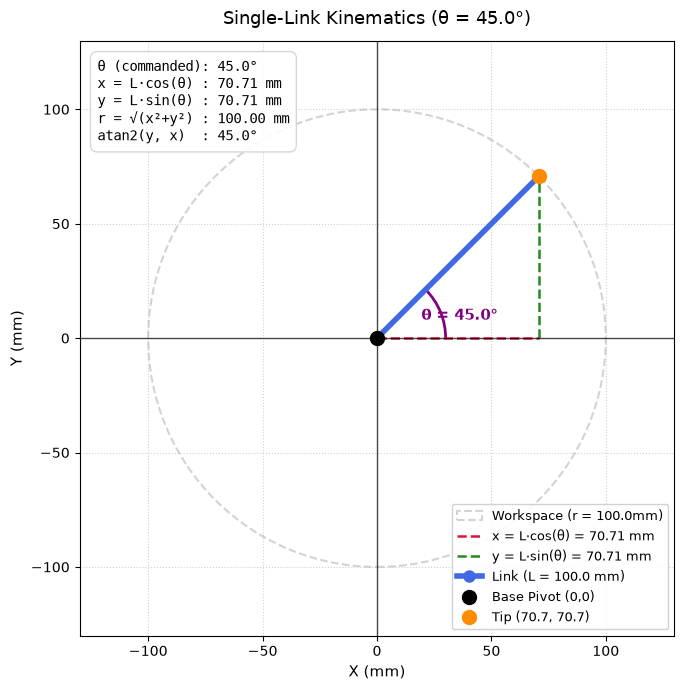

In [ ]:
# --- Arm Configuration ---
L = 100.0          # Link length in mm
theta_deg = 90.0   # Joint angle in degrees

# --- Forward Kinematics Calculations ---
theta_rad = np.radians(theta_deg)
x = L * np.cos(theta_rad)
y = L * np.sin(theta_rad)
r = np.sqrt(x**2 + y**2)
solved_theta_deg = np.degrees(np.arctan2(y, x))

# --- Plotting ---
fig, ax = plt.subplots(figsize=(7, 7))

# 1. Workspace boundary circle (radius = L)
workspace = plt.Circle((0, 0), L, color='lightgray', fill=False, linestyle='--', linewidth=1.5, label=f'Workspace (r = {L}mm)')
ax.add_patch(workspace)

# 2. X and Y projection lines
ax.plot([0, x], [0, 0], '--', color='crimson', linewidth=1.8, label=f'x = L·cos(θ) = {x:.2f} mm')
ax.plot([x, x], [0, y], '--', color='forestgreen', linewidth=1.8, label=f'y = L·sin(θ) = {y:.2f} mm')

# 3. Arm link and joints
ax.plot([0, x], [0, y], '-o', color='royalblue', linewidth=4, markersize=8, label=f'Link (L = {L} mm)')
ax.plot(0, 0, 'ko', markersize=10, label='Base Pivot (0,0)')
ax.plot(x, y, 'o', color='darkorange', markersize=10, zorder=5, label=f'Tip ({x:.1f}, {y:.1f})')

# 4. Angle arc
arc_radius = L * 0.3
angle_arc = Arc((0, 0), 2 * arc_radius, 2 * arc_radius, angle=0,
                theta1=0, theta2=theta_deg, color='purple', linewidth=2)
ax.add_patch(angle_arc)
ax.text(arc_radius * 0.7 * np.cos(theta_rad / 2),
        arc_radius * 0.7 * np.sin(theta_rad / 2),
        f'θ = {theta_deg:.1f}°', color='purple', fontsize=11, fontweight='bold')

# 5. Math / Telemetry summary box
info_box = (
    f"θ (commanded): {theta_deg:.1f}°\n"
    f"x = L·cos(θ) : {x:.2f} mm\n"
    f"y = L·sin(θ) : {y:.2f} mm\n"
    f"r = √(x²+y²) : {r:.2f} mm\n"
    f"atan2(y, x)  : {solved_theta_deg:.1f}°"
)
ax.text(
    0.03, 0.97, info_box,
    transform=ax.transAxes,
    verticalalignment='top',
    fontsize=10,
    family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='lightgray', alpha=0.9)
)

# Styling
limit = L * 1.3
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.6)
ax.axhline(0, color='black', linewidth=1, alpha=0.7)
ax.axvline(0, color='black', linewidth=1, alpha=0.7)
ax.set_xlabel("X (mm)", fontsize=11)
ax.set_ylabel("Y (mm)", fontsize=11)
ax.set_title(f"Single-Link Kinematics (θ = {theta_deg}°)", fontsize=13, pad=12)
ax.legend(loc='lower right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()